# Credit Risk Modelling — Part 2: Exploratory Data Analysis (EDA)
---
**Objective:** Deeply understand the data distributions, relationships between features and the default label, and surface patterns that will guide feature engineering and model selection in Parts 3 & 4.

**EDA Sections:**
1. Setup & data reload
2. Univariate analysis — label & class imbalance
3. Bureau score (`score_1`) deep-dive
4. Feature family overview — discriminative power ranking
5. Family deep-dives: Utilization, Repayment History, Recency, Balance, Spend Behaviour, Credit Limit, Financial Situation
6. Categorical features analysis
7. Correlation heatmap
8. Missingness pattern analysis (linked to default)
9. Key EDA findings & modelling implications

---
## 1 — Setup & Data Reload

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import seaborn as sns
import re
import warnings
from sklearn.metrics import roc_auc_score

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
plt.rcParams.update({"figure.dpi": 110, "font.size": 10})
TRAIN_X = "/Users/parveenkumarsharma/Documents/Ecom_project/Credit_risk_model/MP Credit Modelling Takehome Task (train + test) - X_train.csv"
TEST_X = "/Users/parveenkumarsharma/Documents/Ecom_project/Credit_risk_model/MP Credit Modelling Takehome Task (train + test) - X_test.csv"

TRAIN_Y = "/Users/parveenkumarsharma/Documents/Ecom_project/Credit_risk_model/MP Credit Modelling Takehome Task (train + test) - Y_train.csv"
TEST_Y = "/Users/parveenkumarsharma/Documents/Ecom_project/Credit_risk_model/MP Credit Modelling Takehome Task (train + test) - Y_test.csv"


BLUE, ORANGE, GREEN, RED, PURPLE = "#4472C4","#ED7D31","#70AD47","#C00000","#7030A0"

X_train_raw = pd.read_csv(TRAIN_X)
y_train_raw = pd.read_csv(TRAIN_Y)
X_test_raw  = pd.read_csv(TEST_X)
y_test_raw  = pd.read_csv(TEST_Y)

train = X_train_raw.merge(y_train_raw, on="account_id")
test  = X_test_raw.merge(y_test_raw,   on="account_id")

feature_cols = [c for c in X_train_raw.columns if c != "account_id"]
cat_cols     = [c for c in feature_cols if str(X_train_raw[c].dtype) in ("object","str")]
num_cols     = [c for c in feature_cols if c not in cat_cols]

families = {}
for c in feature_cols:
    m = re.match(r"^([a-z_]+?)_\d+$", c)
    families.setdefault(m.group(1) if m else "other", []).append(c)

print(f"Train: {train.shape} | Test: {test.shape}")
print(f"Families: {sorted(families.keys())}")
print("✓ Data loaded")

Train: (28397, 102) | Test: (4000, 102)
Families: ['balance', 'credit_limit', 'demand_for_credit', 'financial_situation', 'recency', 'repayment_history', 'score', 'spend_behaviour', 'utilization']
✓ Data loaded


---
## 2 — Univariate Analysis: Label & Class Imbalance

The label `1` = defaulted within 12 months after acquisition.  
Understanding the imbalance is the first step — it drives every modelling decision.

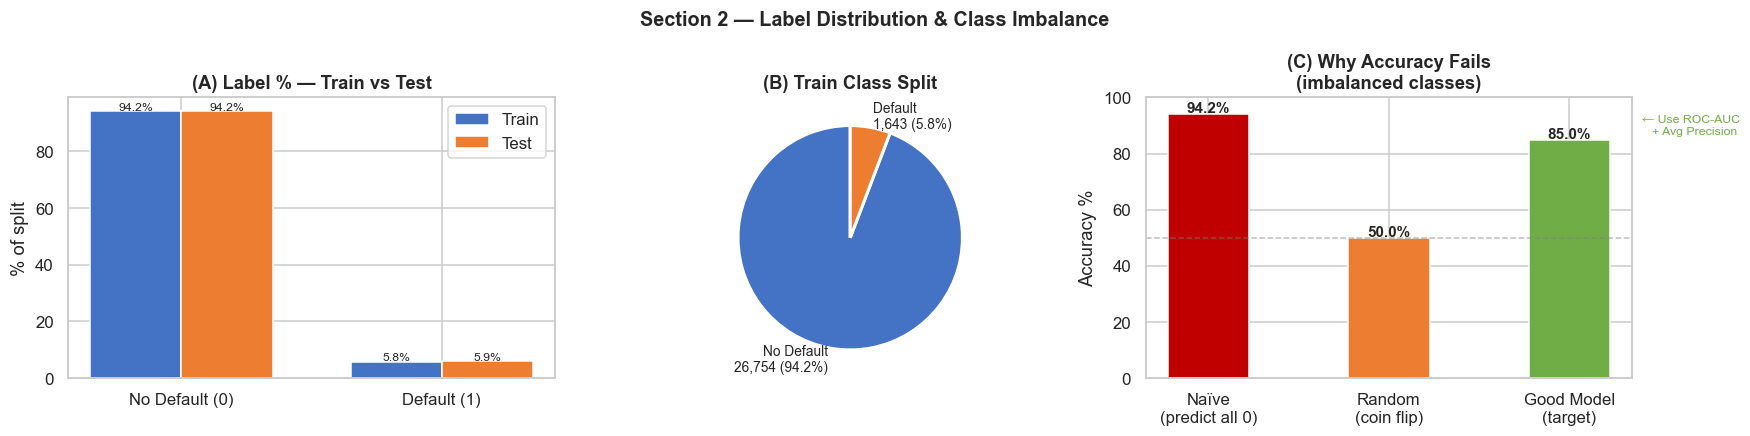


Class imbalance ratio: 16.3:1
Naïve all-zero accuracy: 94.2% — meaningless!
→ We will use ROC-AUC and Average Precision (PR-AUC) as primary metrics


In [2]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle("Section 2 — Label Distribution & Class Imbalance", fontsize=13, fontweight="bold")

# (A) Bar chart — train vs test side by side
ax = axes[0]
train_rates = [1 - train["label"].mean(), train["label"].mean()]
test_rates  = [1 - test["label"].mean(),  test["label"].mean()]
x = np.arange(2); w = 0.35
bars1 = ax.bar(x - w/2, [v*100 for v in train_rates], w, label="Train", color=BLUE,   edgecolor="white")
bars2 = ax.bar(x + w/2, [v*100 for v in test_rates],  w, label="Test",  color=ORANGE, edgecolor="white")
ax.set_xticks(x); ax.set_xticklabels(["No Default (0)", "Default (1)"])
ax.set_ylabel("% of split"); ax.set_title("(A) Label % — Train vs Test", fontweight="bold")
ax.legend()
for bar in list(bars1) + list(bars2):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
            f"{bar.get_height():.1f}%", ha="center", fontsize=8)

# (B) Pie — imbalance visual
ax = axes[1]
sizes  = [train["label"].value_counts()[0], train["label"].value_counts()[1]]
labels = [f"No Default\n{sizes[0]:,} ({sizes[0]/len(train)*100:.1f}%)",
          f"Default\n{sizes[1]:,} ({sizes[1]/len(train)*100:.1f}%)"]
ax.pie(sizes, labels=labels, colors=[BLUE, ORANGE],
       startangle=90, wedgeprops={"edgecolor":"white","linewidth":2},
       textprops={"fontsize":9})
ax.set_title("(B) Train Class Split", fontweight="bold")

# (C) Implication — naive vs smart model
ax = axes[2]
strategies = ["Naïve\n(predict all 0)", "Random\n(coin flip)", "Good Model\n(target)"]
accuracies = [(1-train["label"].mean())*100, 50, 85]
bar_cols   = [RED, ORANGE, GREEN]
bars = ax.bar(strategies, accuracies, color=bar_cols, edgecolor="white", width=0.45)
ax.set_ylim(0, 100); ax.set_ylabel("Accuracy %")
ax.set_title("(C) Why Accuracy Fails\n(imbalanced classes)", fontweight="bold")
for bar, val in zip(bars, accuracies):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
            f"{val:.1f}%", ha="center", fontsize=10, fontweight="bold")
ax.axhline(50, color="gray", linestyle="--", linewidth=1, alpha=0.5)
ax.text(2.4, 87, "← Use ROC-AUC\n   + Avg Precision", fontsize=8, color=GREEN)

plt.tight_layout(); plt.show()

print(f"\nClass imbalance ratio: {train['label'].value_counts()[0]/train['label'].value_counts()[1]:.1f}:1")
print(f"Naïve all-zero accuracy: {(1-train['label'].mean())*100:.1f}% — meaningless!")
print(f"→ We will use ROC-AUC and Average Precision (PR-AUC) as primary metrics")

---
## 3 — Bureau Score (`score_1`) Deep-Dive

`score_1` is the pre-trained credit reference agency score.  
It is our **external benchmark** — any model we build should ideally beat it.  
We explore its distribution, its relationship with default, and its standalone predictive power.

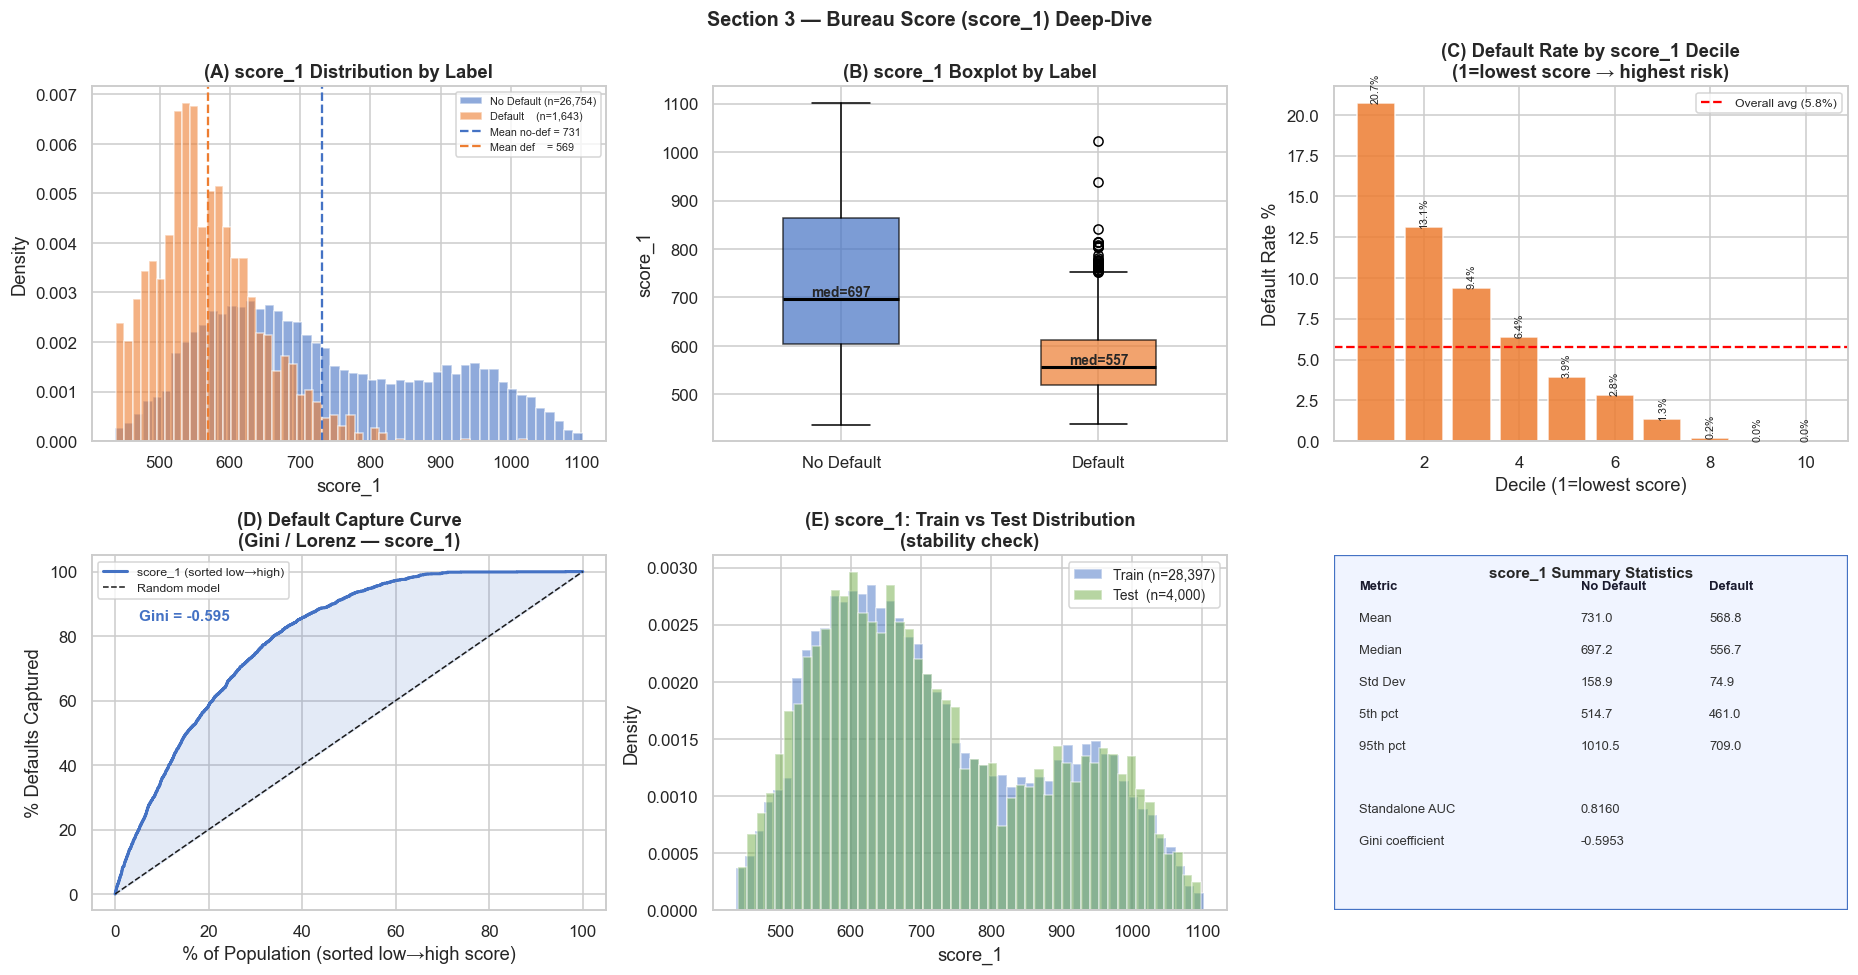


Key finding: score_1 alone achieves AUC = 0.8160
Gini coefficient = -0.5953  (credit industry benchmark: >0.4 is good)


In [3]:
fig, axes = plt.subplots(2, 3, figsize=(17, 9))
fig.suptitle("Section 3 — Bureau Score (score_1) Deep-Dive", fontsize=13, fontweight="bold")

s_def   = train[train["label"]==1]["score_1"].dropna()
s_nodef = train[train["label"]==0]["score_1"].dropna()

# (A) Overlapping histograms
ax = axes[0,0]
ax.hist(s_nodef, bins=50, alpha=0.6, color=BLUE,   density=True, label=f"No Default (n={len(s_nodef):,})")
ax.hist(s_def,   bins=50, alpha=0.6, color=ORANGE, density=True, label=f"Default    (n={len(s_def):,})")
ax.axvline(s_nodef.mean(), color=BLUE,   linestyle="--", lw=1.5, label=f"Mean no-def = {s_nodef.mean():.0f}")
ax.axvline(s_def.mean(),   color=ORANGE, linestyle="--", lw=1.5, label=f"Mean def    = {s_def.mean():.0f}")
ax.set_title("(A) score_1 Distribution by Label", fontweight="bold")
ax.set_xlabel("score_1"); ax.set_ylabel("Density")
ax.legend(fontsize=7)

# (B) Boxplot
ax = axes[0,1]
bp = ax.boxplot([s_nodef, s_def], labels=["No Default","Default"],
                patch_artist=True, widths=0.45,
                medianprops={"color":"black","linewidth":2})
for patch, color in zip(bp["boxes"], [BLUE, ORANGE]):
    patch.set_facecolor(color); patch.set_alpha(0.7)
ax.set_title("(B) score_1 Boxplot by Label", fontweight="bold")
ax.set_ylabel("score_1")
for i, vals in enumerate([s_nodef, s_def]):
    ax.text(i+1, vals.median()+5, f"med={vals.median():.0f}", ha="center", fontsize=9, fontweight="bold")

# (C) Default rate by score decile
ax = axes[0,2]
train_tmp = train.copy()
train_tmp["score_decile"] = pd.qcut(train_tmp["score_1"], q=10, labels=False, duplicates="drop")
dr_decile = train_tmp.groupby("score_decile")["label"].mean() * 100
count_decile = train_tmp.groupby("score_decile")["label"].count()
bars = ax.bar(dr_decile.index + 1, dr_decile.values, color=ORANGE, edgecolor="white", alpha=0.85)
ax.axhline(train["label"].mean()*100, color="red", linestyle="--", lw=1.5, label=f"Overall avg ({train['label'].mean()*100:.1f}%)")
ax.set_title("(C) Default Rate by score_1 Decile\n(1=lowest score → highest risk)", fontweight="bold")
ax.set_xlabel("Decile (1=lowest score)"); ax.set_ylabel("Default Rate %")
ax.legend(fontsize=8)
for bar, val in zip(bars, dr_decile.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.1,
            f"{val:.1f}%", ha="center", fontsize=7, rotation=90)

# (D) Cumulative default capture curve (Lorenz-style)
ax = axes[1,0]
sorted_df = train_tmp.sort_values("score_1")   # low score = high risk
sorted_df["cum_default_pct"] = (sorted_df["label"].cumsum() / sorted_df["label"].sum()) * 100
sorted_df["cum_pop_pct"]     = np.arange(1, len(sorted_df)+1) / len(sorted_df) * 100
ax.plot(sorted_df["cum_pop_pct"], sorted_df["cum_default_pct"],
        color=BLUE, lw=2, label="score_1 (sorted low→high)")
ax.plot([0,100],[0,100], "k--", lw=1, label="Random model")
ax.fill_between(sorted_df["cum_pop_pct"],
                sorted_df["cum_default_pct"],
                sorted_df["cum_pop_pct"], alpha=0.15, color=BLUE)
ax.set_title("(D) Default Capture Curve\n(Gini / Lorenz — score_1)", fontweight="bold")
ax.set_xlabel("% of Population (sorted low→high score)")
ax.set_ylabel("% Defaults Captured")
ax.legend(fontsize=8)

# compute Gini
gini = 1 - 2 * np.trapz(sorted_df["cum_default_pct"]/100,
                          sorted_df["cum_pop_pct"]/100)
ax.text(5, 85, f"Gini = {gini:.3f}", fontsize=10, fontweight="bold", color=BLUE)

# (E) Score distribution — train vs test overlap
ax = axes[1,1]
ax.hist(train["score_1"].dropna(), bins=50, alpha=0.5, color=BLUE,   density=True, label=f"Train (n={len(train):,})")
ax.hist(test["score_1"].dropna(),  bins=50, alpha=0.5, color=GREEN,  density=True, label=f"Test  (n={len(test):,})")
ax.set_title("(E) score_1: Train vs Test Distribution\n(stability check)", fontweight="bold")
ax.set_xlabel("score_1"); ax.set_ylabel("Density")
ax.legend(fontsize=9)

# (F) score_1 stats table
ax = axes[1,2]
ax.axis("off")
ax.add_patch(plt.Rectangle((0,0),1,1, transform=ax.transAxes,
                             facecolor="#F0F4FF", edgecolor="#4472C4", lw=1.5))
stats_data = [
    ["Metric", "No Default", "Default"],
    ["Mean",    f"{s_nodef.mean():.1f}", f"{s_def.mean():.1f}"],
    ["Median",  f"{s_nodef.median():.1f}", f"{s_def.median():.1f}"],
    ["Std Dev", f"{s_nodef.std():.1f}",  f"{s_def.std():.1f}"],
    ["5th pct", f"{s_nodef.quantile(.05):.1f}", f"{s_def.quantile(.05):.1f}"],
    ["95th pct",f"{s_nodef.quantile(.95):.1f}", f"{s_def.quantile(.95):.1f}"],
    ["", "", ""],
    ["Standalone AUC", f"{roc_auc_score(train['label'], -train['score_1']):.4f}", ""],
    ["Gini coefficient", f"{gini:.4f}", ""],
]
col_widths = [0.4, 0.3, 0.3]
y_start = 0.93
ax.text(0.5, 0.97, "score_1 Summary Statistics", transform=ax.transAxes,
        fontsize=10, fontweight="bold", ha="center", va="top")
for row_i, row in enumerate(stats_data):
    y = y_start - row_i * 0.09
    for col_i, (val, w_acc) in enumerate(zip(row, [0.05, 0.48, 0.73])):
        bold = row_i == 0
        ax.text(w_acc, y, val, transform=ax.transAxes,
                fontsize=8.5, fontweight="bold" if bold else "normal",
                va="top", color="#1a1a2e" if bold else "#333")

plt.tight_layout(); plt.show()
print(f"\nKey finding: score_1 alone achieves AUC = {roc_auc_score(train['label'], -train['score_1']):.4f}")
print(f"Gini coefficient = {gini:.4f}  (credit industry benchmark: >0.4 is good)")

---
## 4 — Feature Family Overview: Discriminative Power Ranking

Before diving into each family, we rank all 100 features by:
- **Correlation with label** (absolute Pearson)
- **Standalone AUC** (how well each feature alone separates defaulters from non-defaulters)

This tells us which feature families matter most.

In [4]:
# Compute per-feature AUC and correlation
feature_stats = []
for col in num_cols:
    tmp = train[[col, "label"]].dropna()
    if len(tmp) < 500: continue
    corr = abs(tmp[col].corr(tmp["label"]))
    auc_pos = roc_auc_score(tmp["label"], tmp[col])
    auc     = max(auc_pos, 1 - auc_pos)
    m = re.match(r"^([a-z_]+?)_\d+$", col)
    fam = m.group(1) if m else "other"
    feature_stats.append({"feature": col, "family": fam, "abs_corr": corr, "auc": auc})

feat_df = pd.DataFrame(feature_stats).sort_values("auc", ascending=False)
print(f"Features analysed: {len(feat_df)}")
print(f"\nTop 20 features by standalone AUC:")
print(feat_df[["feature","family","abs_corr","auc"]].head(20).to_string(index=False))

Features analysed: 98

Top 20 features by standalone AUC:
             feature            family  abs_corr      auc
             score_1             score  0.236950 0.815951
           balance_2           balance  0.105930 0.790564
       utilization_2       utilization  0.149780 0.768640
          balance_20           balance  0.090997 0.765418
      credit_limit_2      credit_limit  0.092835 0.747083
 repayment_history_3 repayment_history  0.154466 0.745594
       utilization_1       utilization  0.153979 0.741786
      utilization_16       utilization  0.146339 0.726558
repayment_history_19 repayment_history  0.148813 0.724443
           recency_1           recency  0.124766 0.717388
repayment_history_30 repayment_history  0.066091 0.713941
           recency_7           recency  0.145989 0.699551
 repayment_history_7 repayment_history  0.046637 0.696512
       utilization_6       utilization  0.157292 0.688911
           recency_8           recency  0.113749 0.685815
          bala

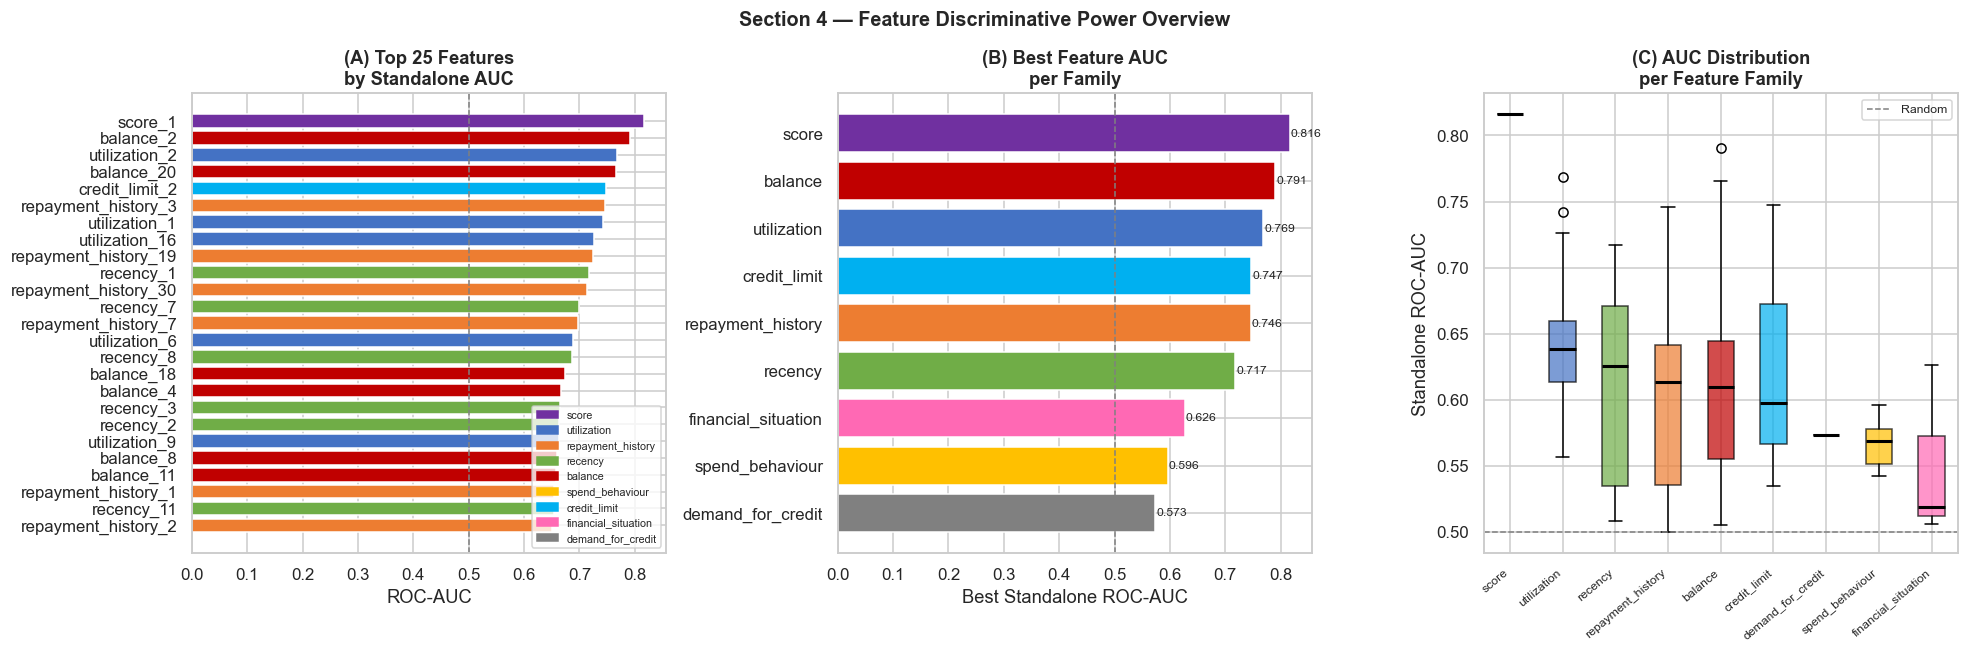


Family ranking (by best-feature AUC):
  score                    : 0.8160  (1 features)
  balance                  : 0.7906  (24 features)
  utilization              : 0.7686  (18 features)
  credit_limit             : 0.7471  (3 features)
  repayment_history        : 0.7456  (31 features)
  recency                  : 0.7174  (12 features)
  financial_situation      : 0.6263  (5 features)
  spend_behaviour          : 0.5958  (5 features)
  demand_for_credit        : 0.5735  (1 features)


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("Section 4 — Feature Discriminative Power Overview", fontsize=13, fontweight="bold")

# (A) Top 25 features by AUC
ax = axes[0]
top25 = feat_df.head(25).sort_values("auc")
fam_color_map = {
    "score": PURPLE, "utilization": BLUE, "repayment_history": ORANGE,
    "recency": GREEN, "balance": RED, "spend_behaviour": "#FFC000",
    "credit_limit": "#00B0F0", "financial_situation": "#FF69B4",
    "demand_for_credit": "#808080"
}
colors = [fam_color_map.get(f, BLUE) for f in top25["family"]]
bars = ax.barh(top25["feature"], top25["auc"], color=colors, edgecolor="white")
ax.axvline(0.5, color="gray", linestyle="--", lw=1, label="Random (AUC=0.5)")
ax.set_title("(A) Top 25 Features\nby Standalone AUC", fontweight="bold")
ax.set_xlabel("ROC-AUC"); ax.legend(fontsize=8)
legend_patches = [mpatches.Patch(color=c, label=f) for f, c in fam_color_map.items()]
ax.legend(handles=legend_patches, fontsize=7, loc="lower right")

# (B) Family-level AUC (best feature per family)
ax = axes[1]
fam_best = feat_df.groupby("family")["auc"].max().sort_values(ascending=True)
fam_colors = [fam_color_map.get(f, BLUE) for f in fam_best.index]
bars = ax.barh(fam_best.index, fam_best.values, color=fam_colors, edgecolor="white")
ax.axvline(0.5, color="gray", linestyle="--", lw=1)
ax.set_title("(B) Best Feature AUC\nper Family", fontweight="bold")
ax.set_xlabel("Best Standalone ROC-AUC")
for bar, val in zip(bars, fam_best.values):
    ax.text(val+0.002, bar.get_y()+bar.get_height()/2,
            f"{val:.3f}", va="center", fontsize=8)

# (C) AUC distribution by family (boxplot)
ax = axes[2]
fam_order = feat_df.groupby("family")["auc"].median().sort_values(ascending=False).index
data_by_fam = [feat_df[feat_df["family"]==f]["auc"].values for f in fam_order]
bp = ax.boxplot(data_by_fam, labels=fam_order, patch_artist=True, vert=True,
                medianprops={"color":"black","lw":2})
for patch, fam in zip(bp["boxes"], fam_order):
    patch.set_facecolor(fam_color_map.get(fam, BLUE)); patch.set_alpha(0.7)
ax.axhline(0.5, color="gray", linestyle="--", lw=1, label="Random")
ax.set_title("(C) AUC Distribution\nper Feature Family", fontweight="bold")
ax.set_ylabel("Standalone ROC-AUC"); ax.legend(fontsize=8)
plt.setp(ax.get_xticklabels(), rotation=40, ha="right", fontsize=8)

plt.tight_layout(); plt.show()

print("\nFamily ranking (by best-feature AUC):")
for fam, auc in fam_best.sort_values(ascending=False).items():
    n = len(families.get(fam, []))
    print(f"  {fam:<25}: {auc:.4f}  ({n} features)")

---
## 5 — Feature Family Deep-Dives

We now explore each major family in detail, looking at:
- Distribution of top feature(s) by label
- Default rate pattern
- Missingness pattern

### 5.1 — Utilization Features
`utilization` = credit used / credit limit. High utilization is a classic default signal.

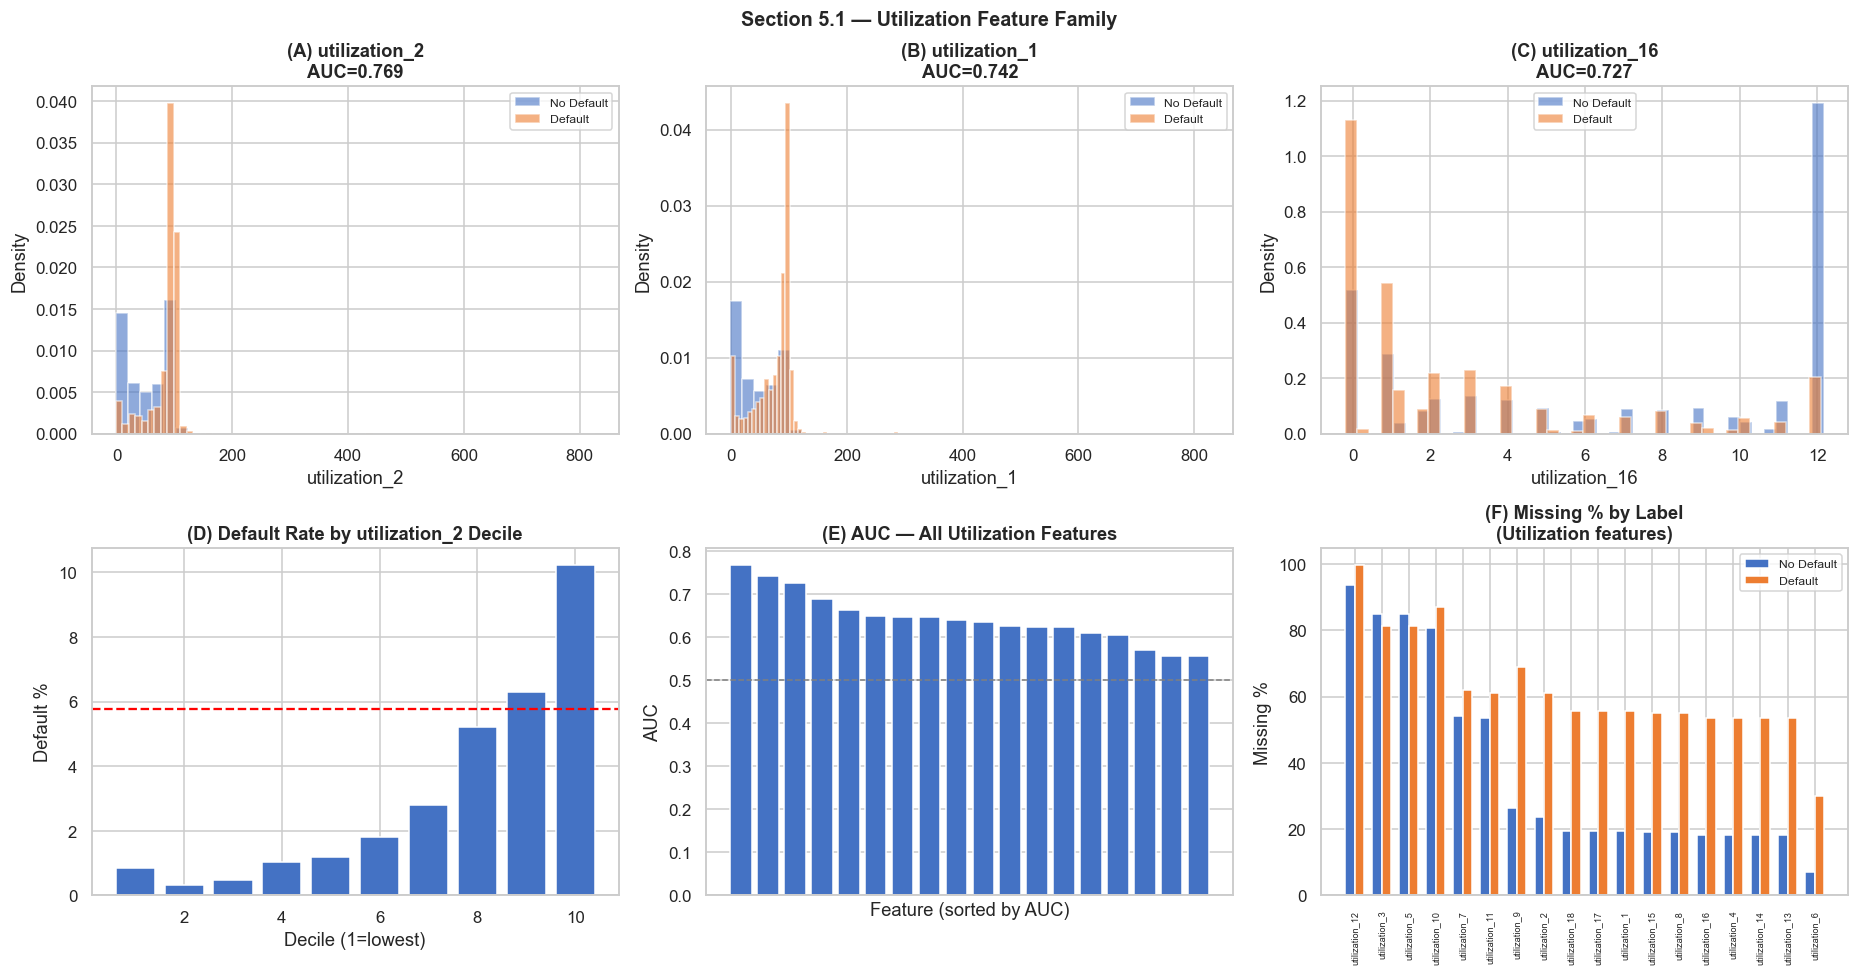

In [7]:
util_cols = sorted(families["utilization"])
util_num  = [c for c in util_cols if c in num_cols]

# top 3 by AUC
top_util = feat_df[feat_df["family"]=="utilization"].sort_values("auc", ascending=False)["feature"].head(3).tolist()

fig, axes = plt.subplots(2, 3, figsize=(17, 9))
fig.suptitle("Section 5.1 — Utilization Feature Family", fontsize=13, fontweight="bold")

for idx, col in enumerate(top_util):
    ax = axes[0, idx]
    for lbl, color, name in [(0,BLUE,"No Default"),(1,ORANGE,"Default")]:
        vals = train[train["label"]==lbl][col].dropna()
        ax.hist(vals, bins=40, alpha=0.6, color=color, density=True, label=name)
    ax.set_title(f"({chr(65+idx)}) {col}\nAUC={feat_df[feat_df['feature']==col]['auc'].values[0]:.3f}", fontweight="bold")
    ax.set_xlabel(col); ax.set_ylabel("Density")
    ax.legend(fontsize=8)

# Default rate by utilization_6 decile (top feature)
ax = axes[1, 0]
top_col = top_util[0]
tmp = train[[top_col,"label"]].dropna().copy()
tmp["decile"] = pd.qcut(tmp[top_col], q=10, labels=False, duplicates="drop")
dr = tmp.groupby("decile")["label"].mean()*100
ax.bar(dr.index+1, dr.values, color=BLUE, edgecolor="white")
ax.axhline(train["label"].mean()*100, color="red", linestyle="--", lw=1.5)
ax.set_title(f"(D) Default Rate by {top_col} Decile", fontweight="bold")
ax.set_xlabel("Decile (1=lowest)"); ax.set_ylabel("Default %")

# Utilization family AUC bar
ax = axes[1, 1]
util_auc = feat_df[feat_df["family"]=="utilization"].sort_values("auc", ascending=False)
ax.bar(range(len(util_auc)), util_auc["auc"].values, color=BLUE, edgecolor="white")
ax.axhline(0.5, color="gray", linestyle="--", lw=1)
ax.set_title("(E) AUC — All Utilization Features", fontweight="bold")
ax.set_xlabel("Feature (sorted by AUC)"); ax.set_ylabel("AUC"); ax.set_xticks([])

# Missingness by label
ax = axes[1, 2]
miss_by_label = {}
for lbl in [0,1]:
    miss_by_label[lbl] = train[train["label"]==lbl][util_num].isnull().mean()*100
miss_df_plot = pd.DataFrame(miss_by_label).sort_values(0, ascending=False)
x = np.arange(len(miss_df_plot)); w=0.35
ax.bar(x-w/2, miss_df_plot[0], w, label="No Default", color=BLUE,   edgecolor="white")
ax.bar(x+w/2, miss_df_plot[1], w, label="Default",    color=ORANGE, edgecolor="white")
ax.set_title("(F) Missing % by Label\n(Utilization features)", fontweight="bold")
ax.set_ylabel("Missing %"); ax.set_xticks(x); ax.set_xticklabels(miss_df_plot.index, rotation=90, fontsize=6)
ax.legend(fontsize=8)

plt.tight_layout(); plt.show()

### 5.2 — Repayment History Features
Repayment history = how many months/events of on-time vs late payments. Key credit risk signal.

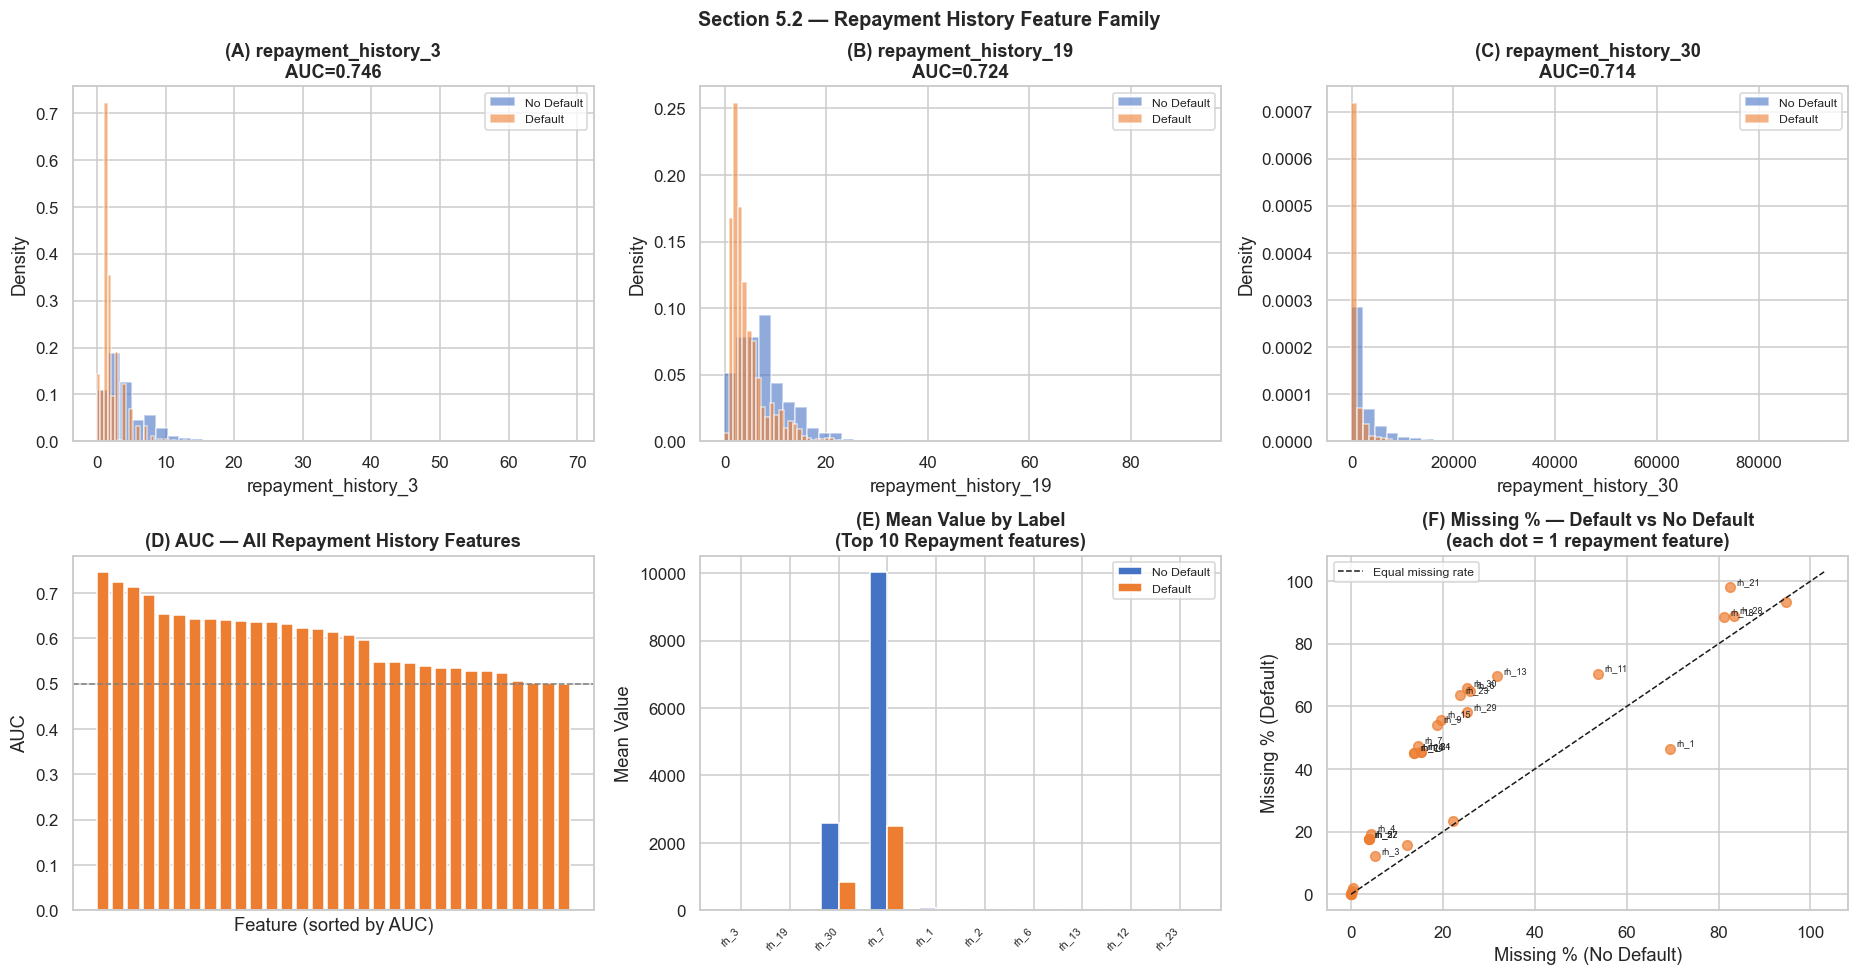

Key: Defaults have HIGHER null % in repayment features → they have LESS repayment history on record


In [8]:
rep_cols = families["repayment_history"]
rep_num  = [c for c in rep_cols if c in num_cols]
top_rep  = feat_df[feat_df["family"]=="repayment_history"].sort_values("auc", ascending=False)["feature"].head(3).tolist()

fig, axes = plt.subplots(2, 3, figsize=(17, 9))
fig.suptitle("Section 5.2 — Repayment History Feature Family", fontsize=13, fontweight="bold")

for idx, col in enumerate(top_rep):
    ax = axes[0, idx]
    for lbl, color, name in [(0,BLUE,"No Default"),(1,ORANGE,"Default")]:
        vals = train[train["label"]==lbl][col].dropna()
        ax.hist(vals, bins=40, alpha=0.6, color=color, density=True, label=name)
    auc_val = feat_df[feat_df["feature"]==col]["auc"].values[0]
    ax.set_title(f"({chr(65+idx)}) {col}\nAUC={auc_val:.3f}", fontweight="bold")
    ax.set_xlabel(col); ax.set_ylabel("Density"); ax.legend(fontsize=8)

# All repayment AUCs
ax = axes[1, 0]
rep_auc = feat_df[feat_df["family"]=="repayment_history"].sort_values("auc", ascending=False)
ax.bar(range(len(rep_auc)), rep_auc["auc"].values, color=ORANGE, edgecolor="white")
ax.axhline(0.5, color="gray", linestyle="--", lw=1)
ax.set_title("(D) AUC — All Repayment History Features", fontweight="bold")
ax.set_xlabel("Feature (sorted by AUC)"); ax.set_ylabel("AUC"); ax.set_xticks([])

# Mean value by label — top 10 repayment features
ax = axes[1, 1]
top10_rep = feat_df[feat_df["family"]=="repayment_history"].sort_values("auc", ascending=False)["feature"].head(10).tolist()
means = train.groupby("label")[top10_rep].mean().T
x = np.arange(len(top10_rep)); w=0.35
ax.bar(x-w/2, means[0].values, w, label="No Default", color=BLUE,   edgecolor="white")
ax.bar(x+w/2, means[1].values, w, label="Default",    color=ORANGE, edgecolor="white")
ax.set_title("(E) Mean Value by Label\n(Top 10 Repayment features)", fontweight="bold")
ax.set_ylabel("Mean Value"); ax.set_xticks(x)
ax.set_xticklabels([c.replace("repayment_history_","rh_") for c in top10_rep], rotation=45, ha="right", fontsize=7)
ax.legend(fontsize=8)

# Null % by label — repayment features
ax = axes[1, 2]
null_nodef = train[train["label"]==0][rep_num].isnull().mean()*100
null_def   = train[train["label"]==1][rep_num].isnull().mean()*100
ax.scatter(null_nodef.values, null_def.values, alpha=0.7, color=ORANGE, s=40)
lim = max(null_nodef.max(), null_def.max()) * 1.05
ax.plot([0,lim],[0,lim],"k--",lw=1,label="Equal missing rate")
ax.set_title("(F) Missing % — Default vs No Default\n(each dot = 1 repayment feature)", fontweight="bold")
ax.set_xlabel("Missing % (No Default)"); ax.set_ylabel("Missing % (Default)")
ax.legend(fontsize=8)
# Annotate those above the diagonal
for col in rep_num:
    nd = null_nodef[col]; d = null_def[col]
    if abs(d - nd) > 5:
        ax.annotate(col.replace("repayment_history_","rh_"), (nd, d),
                    fontsize=6, textcoords="offset points", xytext=(4,2))

plt.tight_layout(); plt.show()
print(f"Key: Defaults have HIGHER null % in repayment features → they have LESS repayment history on record")

### 5.3 — Recency Features
`recency_N` = months since a credit event. **NaN = the event never occurred**, which is itself a strong signal.

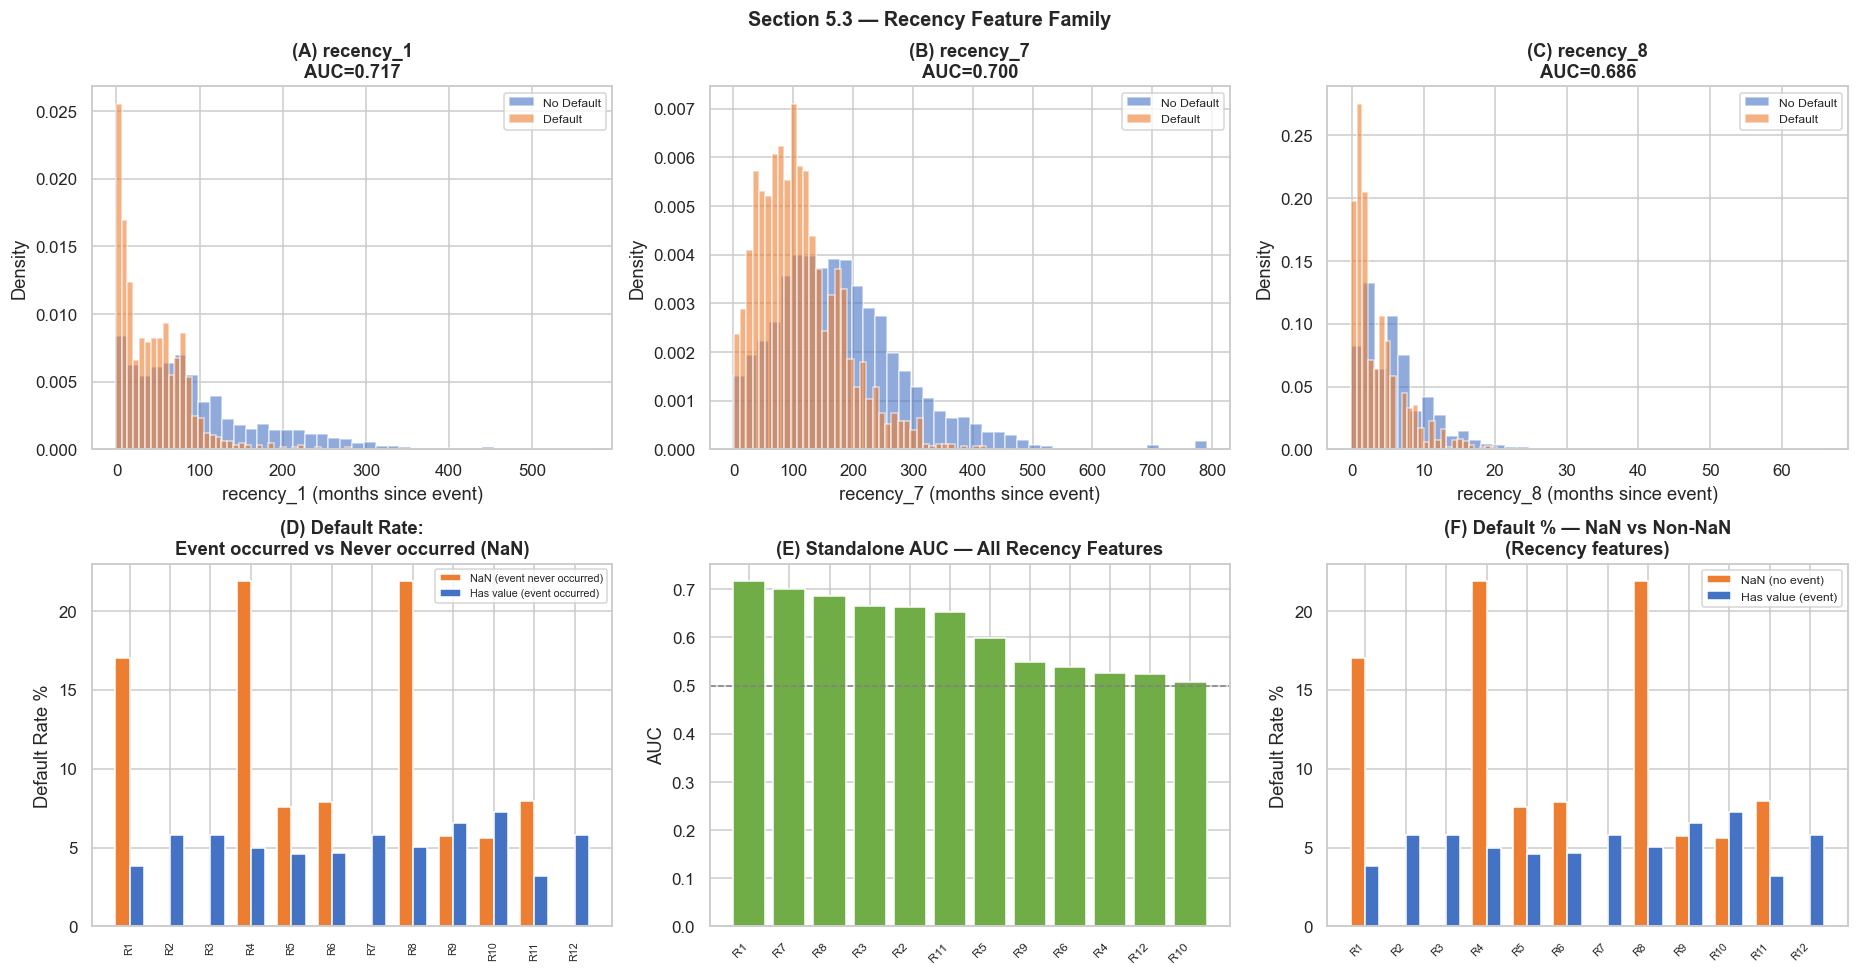

Key: For most recency features, NaN (event never occurred) is associated with LOWER default rate
     → absence of a negative event is a positive signal


In [9]:
rec_cols = families["recency"]
rec_num  = [c for c in rec_cols if c in num_cols]
top_rec  = feat_df[feat_df["family"]=="recency"].sort_values("auc", ascending=False)["feature"].head(3).tolist()

fig, axes = plt.subplots(2, 3, figsize=(17, 9))
fig.suptitle("Section 5.3 — Recency Feature Family", fontsize=13, fontweight="bold")

for idx, col in enumerate(top_rec):
    ax = axes[0, idx]
    for lbl, color, name in [(0,BLUE,"No Default"),(1,ORANGE,"Default")]:
        vals = train[train["label"]==lbl][col].dropna()
        ax.hist(vals, bins=40, alpha=0.6, color=color, density=True, label=name)
    auc_val = feat_df[feat_df["feature"]==col]["auc"].values[0]
    ax.set_title(f"({chr(65+idx)}) {col}\nAUC={auc_val:.3f}", fontweight="bold")
    ax.set_xlabel(col+" (months since event)"); ax.set_ylabel("Density"); ax.legend(fontsize=8)

# Default rate: has-event vs no-event (NaN = no event)
ax = axes[1, 0]
event_dr, no_event_dr, col_names = [], [], []
for col in rec_num:
    has_event   = train[train[col].notna()]["label"].mean()*100
    no_event    = train[train[col].isna()]["label"].mean()*100
    event_dr.append(has_event); no_event_dr.append(no_event)
    col_names.append(col.replace("recency_","R"))
x = np.arange(len(rec_num)); w=0.35
ax.bar(x-w/2, no_event_dr, w, label="NaN (event never occurred)", color=ORANGE, edgecolor="white")
ax.bar(x+w/2, event_dr,    w, label="Has value (event occurred)", color=BLUE,   edgecolor="white")
ax.set_title("(D) Default Rate:\nEvent occurred vs Never occurred (NaN)", fontweight="bold")
ax.set_ylabel("Default Rate %"); ax.set_xticks(x)
ax.set_xticklabels(col_names, rotation=90, fontsize=7); ax.legend(fontsize=7)

# Recency AUC ranking
ax = axes[1, 1]
rec_auc = feat_df[feat_df["family"]=="recency"].sort_values("auc", ascending=False)
ax.bar(range(len(rec_auc)), rec_auc["auc"].values, color=GREEN, edgecolor="white")
ax.axhline(0.5, color="gray", linestyle="--", lw=1)
ax.set_xticks(range(len(rec_auc)))
ax.set_xticklabels(rec_auc["feature"].str.replace("recency_","R"), rotation=45, ha="right", fontsize=8)
ax.set_title("(E) Standalone AUC — All Recency Features", fontweight="bold")
ax.set_ylabel("AUC")

# Null indicator default rate
ax = axes[1, 2]
null_def_rates = []
for col in rec_num:
    rate_null     = train[train[col].isna()]["label"].mean()*100
    rate_not_null = train[train[col].notna()]["label"].mean()*100
    null_def_rates.append({"feature": col.replace("recency_","R"),
                            "NaN_default%": rate_null, "Has_value_default%": rate_not_null})
ndr = pd.DataFrame(null_def_rates).set_index("feature")
x = np.arange(len(ndr)); w=0.35
ax.bar(x-w/2, ndr["NaN_default%"],       w, label="NaN (no event)",    color=ORANGE, edgecolor="white")
ax.bar(x+w/2, ndr["Has_value_default%"], w, label="Has value (event)", color=BLUE,   edgecolor="white")
ax.set_xticks(x); ax.set_xticklabels(ndr.index, rotation=45, ha="right", fontsize=7)
ax.set_title("(F) Default % — NaN vs Non-NaN\n(Recency features)", fontweight="bold")
ax.set_ylabel("Default Rate %"); ax.legend(fontsize=8)

plt.tight_layout(); plt.show()
print("Key: For most recency features, NaN (event never occurred) is associated with LOWER default rate")
print("     → absence of a negative event is a positive signal")

### 5.4 — Balance Features
`balance_N` = outstanding balance on various credit products. High balance can signal over-extension.

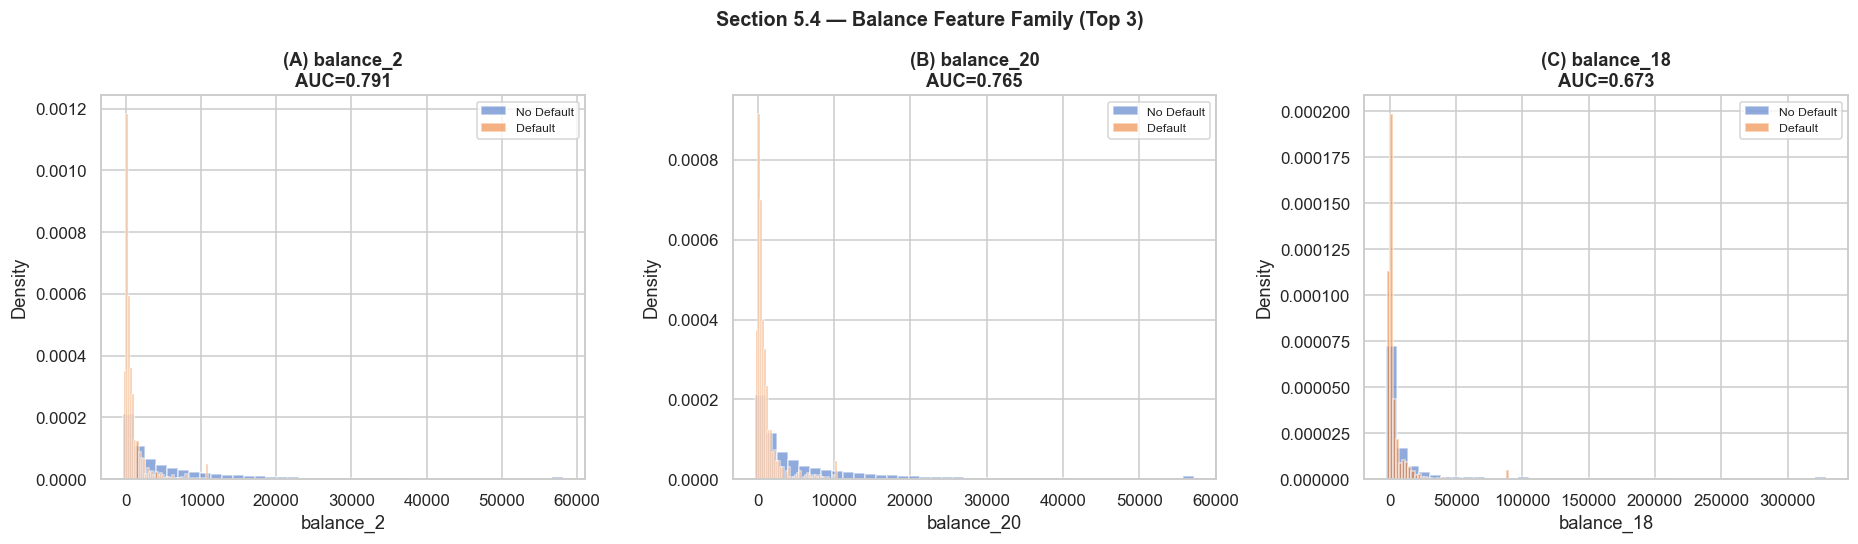

Balance family — top features by AUC:
   feature      auc  abs_corr
 balance_2 0.790564  0.105930
balance_20 0.765418  0.090997
balance_18 0.673031  0.073472
 balance_4 0.667118  0.072815
 balance_8 0.660139  0.130545
balance_11 0.657209  0.091815
 balance_1 0.640441  0.128693
 balance_3 0.640345  0.089185


In [10]:
bal_cols = families["balance"]
bal_num  = [c for c in bal_cols if c in num_cols]
top_bal  = feat_df[feat_df["family"]=="balance"].sort_values("auc", ascending=False)["feature"].head(3).tolist()

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle("Section 5.4 — Balance Feature Family (Top 3)", fontsize=13, fontweight="bold")

for idx, col in enumerate(top_bal):
    ax = axes[idx]
    for lbl, color, name in [(0,BLUE,"No Default"),(1,ORANGE,"Default")]:
        vals = train[train["label"]==lbl][col].dropna()
        # clip at 99th pct for readability
        cap = vals.quantile(0.99)
        vals = vals.clip(upper=cap)
        ax.hist(vals, bins=40, alpha=0.6, color=color, density=True, label=name)
    auc_val = feat_df[feat_df["feature"]==col]["auc"].values[0]
    ax.set_title(f"({chr(65+idx)}) {col}\nAUC={auc_val:.3f}", fontweight="bold")
    ax.set_xlabel(col); ax.set_ylabel("Density"); ax.legend(fontsize=8)

plt.tight_layout(); plt.show()

# Summary table
print("Balance family — top features by AUC:")
print(feat_df[feat_df["family"]=="balance"].sort_values("auc", ascending=False)
      [["feature","auc","abs_corr"]].head(8).to_string(index=False))

### 5.5 — Spend Behaviour & Other Families
A quick look at spend behaviour, credit limit, demand for credit, and financial situation (numeric).

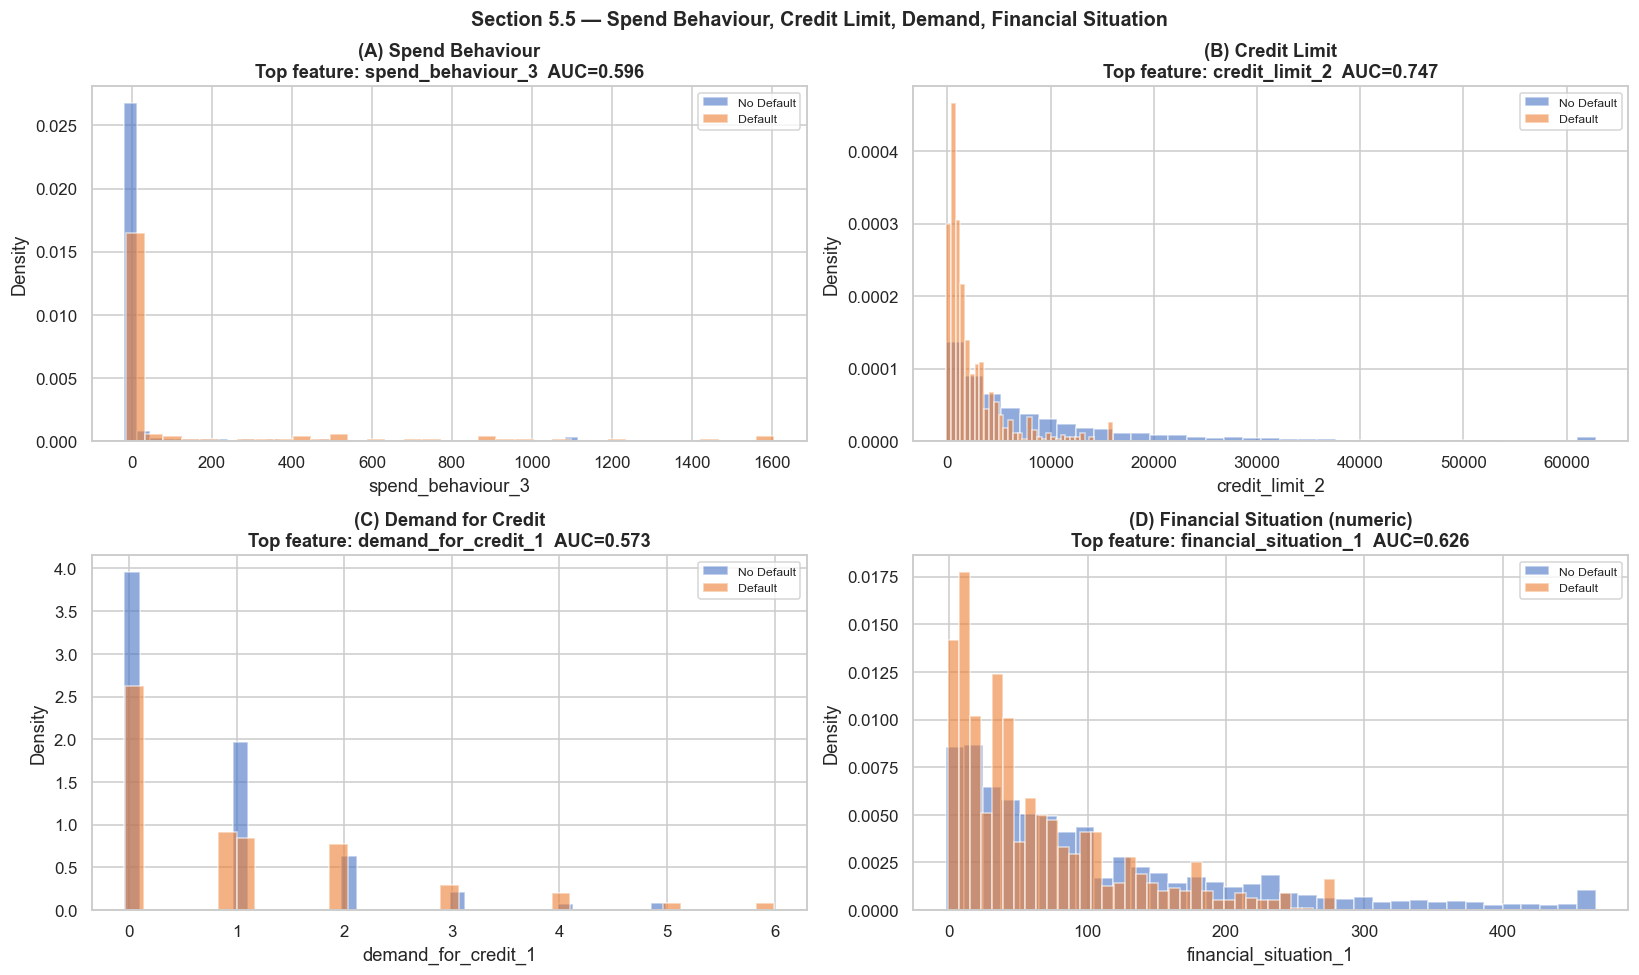

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(15, 9))
fig.suptitle("Section 5.5 — Spend Behaviour, Credit Limit, Demand, Financial Situation", fontsize=13, fontweight="bold")

small_families = ["spend_behaviour", "credit_limit", "demand_for_credit", "financial_situation"]
titles = ["Spend Behaviour", "Credit Limit", "Demand for Credit", "Financial Situation (numeric)"]

for idx, (fam, title) in enumerate(zip(small_families, titles)):
    ax = axes[idx//2, idx%2]
    fam_num = [c for c in families.get(fam,[]) if c in num_cols]
    if not fam_num:
        ax.axis("off"); continue
    top_col = feat_df[feat_df["family"]==fam].sort_values("auc", ascending=False)["feature"].iloc[0]
    for lbl, color, name in [(0,BLUE,"No Default"),(1,ORANGE,"Default")]:
        vals = train[train["label"]==lbl][top_col].dropna()
        cap = vals.quantile(0.99); vals = vals.clip(upper=cap)
        ax.hist(vals, bins=35, alpha=0.6, color=color, density=True, label=name)
    auc_val = feat_df[feat_df["feature"]==top_col]["auc"].values[0]
    ax.set_title(f"({chr(65+idx)}) {title}\nTop feature: {top_col}  AUC={auc_val:.3f}", fontweight="bold")
    ax.set_xlabel(top_col); ax.set_ylabel("Density"); ax.legend(fontsize=8)

plt.tight_layout(); plt.show()

---
## 6 — Categorical Features Analysis

`financial_situation_4` and `financial_situation_5` are the two categorical features.  
We examine default rates per category and the volume distribution.

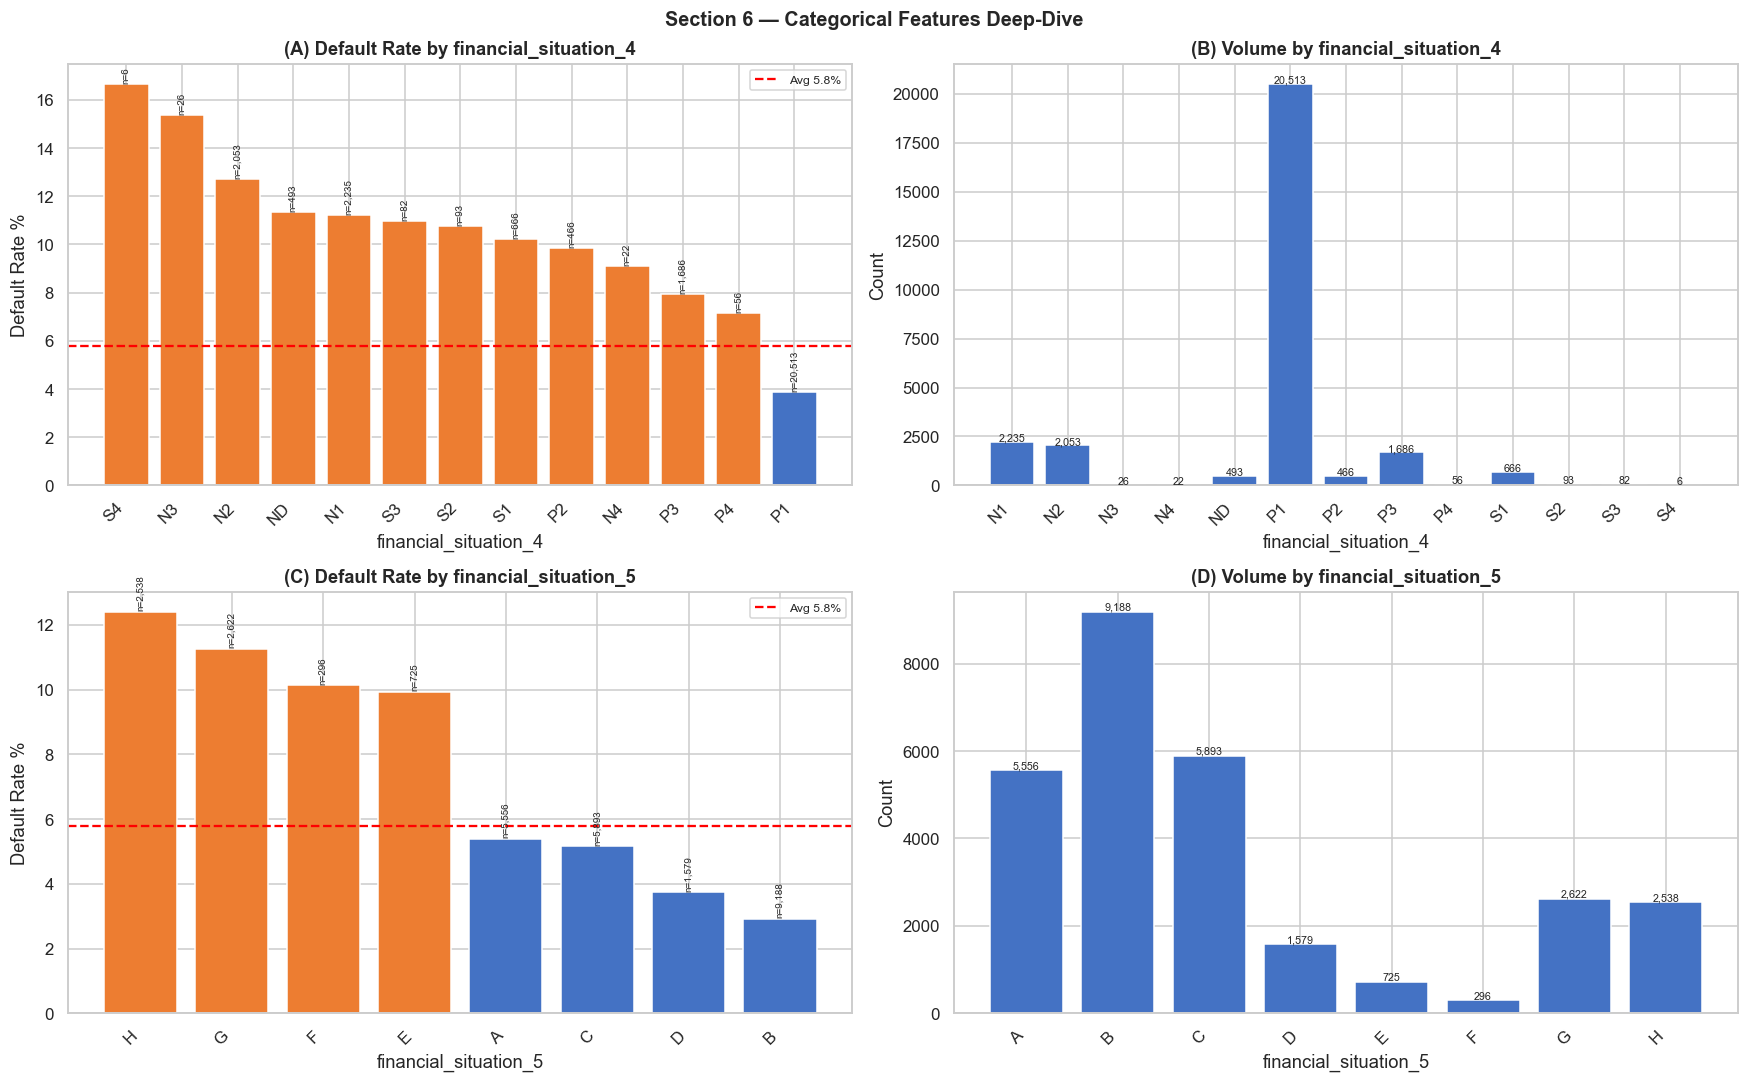


Categorical features — default rate spread:
  financial_situation_4: min=3.9%  max=16.7%  range=12.8pp
  financial_situation_5: min=2.9%  max=12.4%  range=9.5pp


In [12]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle("Section 6 — Categorical Features Deep-Dive", fontsize=13, fontweight="bold")

for i, col in enumerate(cat_cols):
    # ── Default rate by category
    ax = axes[i][0]
    dr = (train.groupby(col)["label"]
               .agg(["mean","count"])
               .reset_index()
               .assign(dr_pct=lambda x: x["mean"]*100)
               .sort_values("dr_pct", ascending=False))
    avg_dr = train["label"].mean()*100
    bar_colors = [ORANGE if v > avg_dr else BLUE for v in dr["dr_pct"]]
    bars = ax.bar(dr[col].astype(str), dr["dr_pct"], color=bar_colors, edgecolor="white")
    ax.axhline(avg_dr, color="red", linestyle="--", lw=1.5, label=f"Avg {avg_dr:.1f}%")
    ax.set_title(f"({chr(65+i*2)}) Default Rate by {col}", fontweight="bold")
    ax.set_ylabel("Default Rate %"); ax.set_xlabel(col); ax.legend(fontsize=8)
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
    for bar, (_, row) in zip(bars, dr.iterrows()):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.1,
                f"n={int(row['count']):,}", ha="center", fontsize=6.5, rotation=90)

    # ── Volume by category
    ax = axes[i][1]
    vol = train[col].value_counts().sort_index()
    ax.bar(vol.index.astype(str), vol.values, color=BLUE, edgecolor="white")
    ax.set_title(f"({chr(66+i*2)}) Volume by {col}", fontweight="bold")
    ax.set_ylabel("Count"); ax.set_xlabel(col)
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
    for x_pos, (cat, cnt) in enumerate(vol.items()):
        ax.text(x_pos, cnt+30, f"{cnt:,}", ha="center", fontsize=7)

plt.tight_layout(); plt.show()

# Print AUC for categorical features (encode ordinally for quick AUC)
print("\nCategorical features — default rate spread:")
for col in cat_cols:
    dr = train.groupby(col)["label"].mean()*100
    print(f"  {col}: min={dr.min():.1f}%  max={dr.max():.1f}%  range={dr.max()-dr.min():.1f}pp")

---
## 7 — Correlation Analysis

We look at:
1. **Inter-feature correlations** — are features redundant within the same family?
2. **Correlation with the label** — ranked bar chart

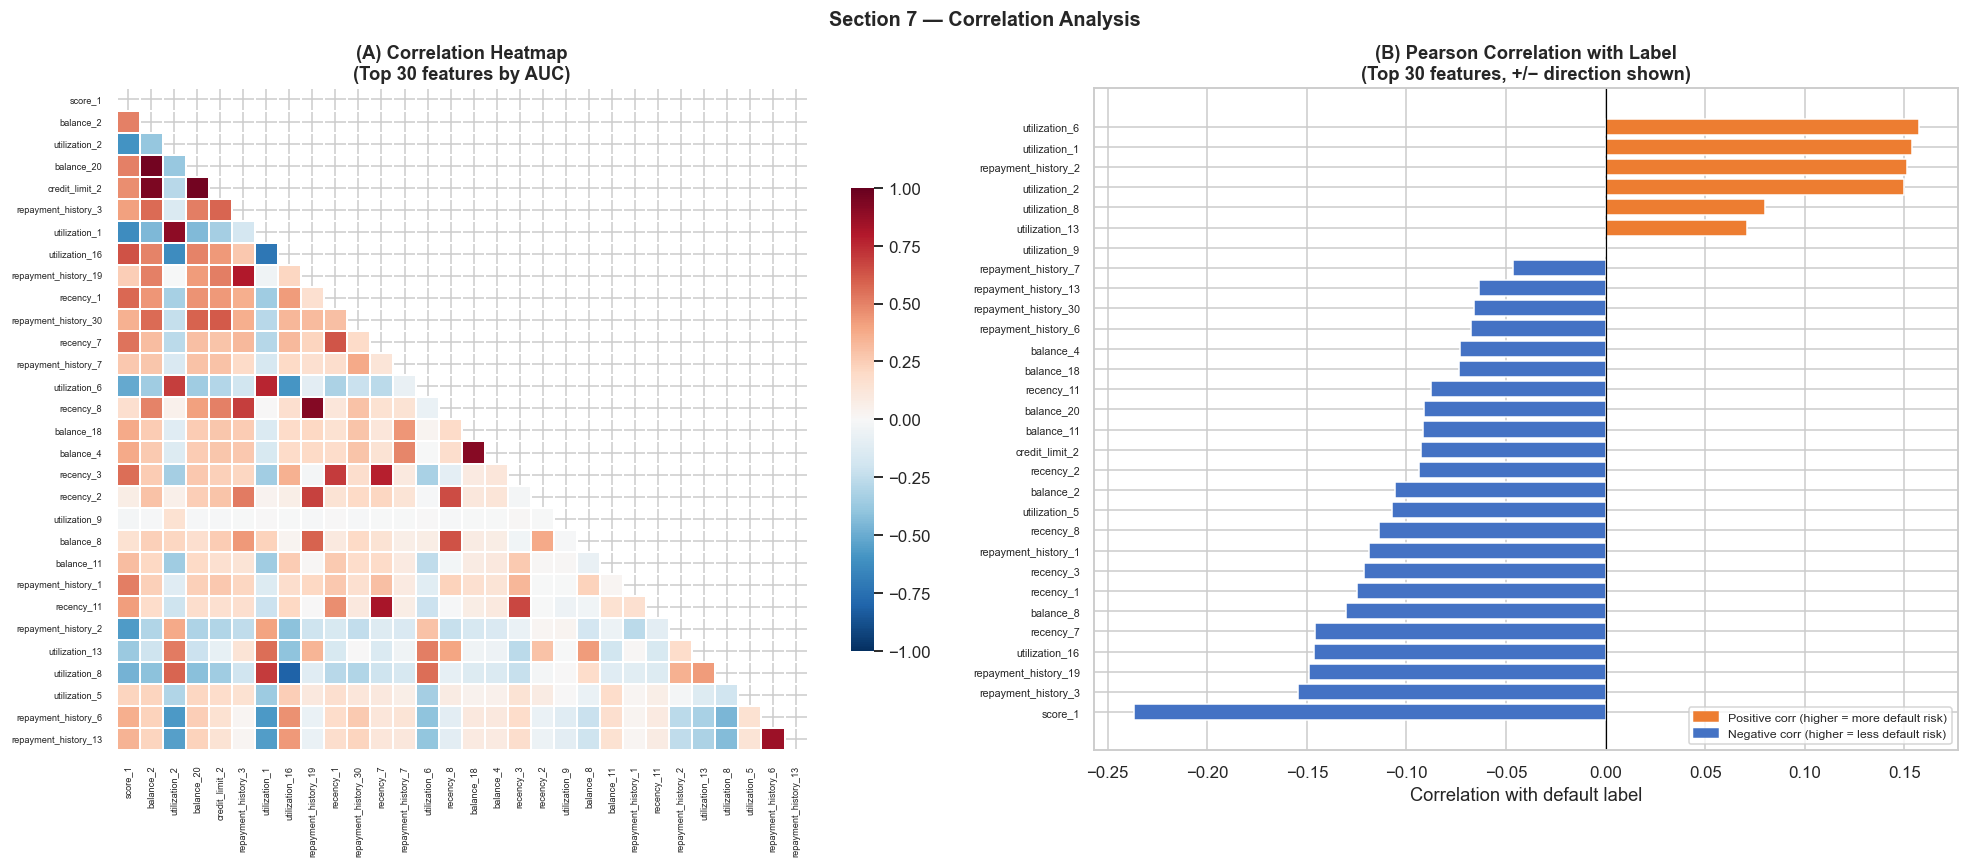


Highly correlated pairs (|r| > 0.85) among top 30 features:
  balance_2                           ↔  balance_20                           r=0.967
  balance_2                           ↔  credit_limit_2                       r=0.944
  utilization_2                       ↔  utilization_1                        r=0.896
  balance_20                          ↔  credit_limit_2                       r=0.963
  repayment_history_19                ↔  recency_8                            r=0.915
  balance_18                          ↔  balance_4                            r=0.910
  repayment_history_6                 ↔  repayment_history_13                 r=0.859


In [13]:
# Top 30 features by AUC for heatmap (manageable size)
top30_cols = feat_df.head(30)["feature"].tolist()

fig, axes = plt.subplots(1, 2, figsize=(18, 8))
fig.suptitle("Section 7 — Correlation Analysis", fontsize=13, fontweight="bold")

# (A) Heatmap of top 30 features
ax = axes[0]
corr_matrix = train[top30_cols].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, ax=ax, cmap="RdBu_r",
            center=0, vmin=-1, vmax=1,
            xticklabels=True, yticklabels=True,
            linewidths=0.3, cbar_kws={"shrink":0.7})
ax.set_title("(A) Correlation Heatmap\n(Top 30 features by AUC)", fontweight="bold")
ax.tick_params(axis="x", labelsize=6, rotation=90)
ax.tick_params(axis="y", labelsize=6)

# (B) Correlation with label — top 30
ax = axes[1]
label_corr = train[top30_cols + ["label"]].corr()["label"].drop("label").sort_values()
bar_colors = [ORANGE if v > 0 else BLUE for v in label_corr.values]
ax.barh(range(len(label_corr)), label_corr.values, color=bar_colors, edgecolor="white")
ax.set_yticks(range(len(label_corr)))
ax.set_yticklabels(label_corr.index, fontsize=7)
ax.axvline(0, color="black", lw=0.8)
ax.set_title("(B) Pearson Correlation with Label\n(Top 30 features, +/− direction shown)", fontweight="bold")
ax.set_xlabel("Correlation with default label")
pos_patch = mpatches.Patch(color=ORANGE, label="Positive corr (higher = more default risk)")
neg_patch = mpatches.Patch(color=BLUE,   label="Negative corr (higher = less default risk)")
ax.legend(handles=[pos_patch, neg_patch], fontsize=8, loc="lower right")

plt.tight_layout(); plt.show()

# Highly correlated pairs within families
print("\nHighly correlated pairs (|r| > 0.85) among top 30 features:")
found = False
for i in range(len(top30_cols)):
    for j in range(i+1, len(top30_cols)):
        r = corr_matrix.iloc[i,j]
        if abs(r) > 0.85:
            print(f"  {top30_cols[i]:<35} ↔  {top30_cols[j]:<35}  r={r:.3f}")
            found = True
if not found:
    print("  None found — features are relatively independent")

---
## 8 — Missingness Pattern Analysis

A key insight: **the fact that a value is missing is itself predictive**.  
Customers with no balance / no repayment history on a product are different from those who have it.

In [14]:
# Compute: default rate when value is NaN vs when value is present
miss_signal = []
for col in num_cols:
    n_null = train[col].isnull().sum()
    if n_null < 100: continue   # not enough nulls to be meaningful
    dr_null     = train[train[col].isnull()]["label"].mean()*100
    dr_not_null = train[train[col].notna()]["label"].mean()*100
    diff = dr_null - dr_not_null
    m = re.match(r"^([a-z_]+?)_\d+$", col)
    fam = m.group(1) if m else "other"
    miss_signal.append({"feature": col, "family": fam,
                        "null_pct": n_null/len(train)*100,
                        "dr_when_null": dr_null,
                        "dr_when_present": dr_not_null,
                        "diff_pp": diff})

ms_df = pd.DataFrame(miss_signal).sort_values("diff_pp", key=abs, ascending=False)
print("Top 20 features where missingness most changes default rate:")
print(ms_df[["feature","null_pct","dr_when_null","dr_when_present","diff_pp"]].head(20).round(2).to_string(index=False))

Top 20 features where missingness most changes default rate:
             feature  null_pct  dr_when_null  dr_when_present  diff_pp
repayment_history_19      0.48         22.79             5.70    17.09
           recency_8      4.63         21.90             5.00    16.90
repayment_history_22      4.63         21.90             5.00    16.90
repayment_history_27      4.63         21.90             5.00    16.90
 repayment_history_5      4.63         21.90             5.00    16.90
           recency_4      4.65         21.88             5.00    16.88
          balance_12      8.33         21.01             4.40    16.61
 repayment_history_4      5.20         21.46             4.93    16.54
       utilization_6      8.32         20.90             4.41    16.48
          balance_10      5.98         20.68             4.84    15.84
           balance_8      6.27         20.49             4.80    15.69
           balance_1      6.27         20.49             4.80    15.69
          balanc

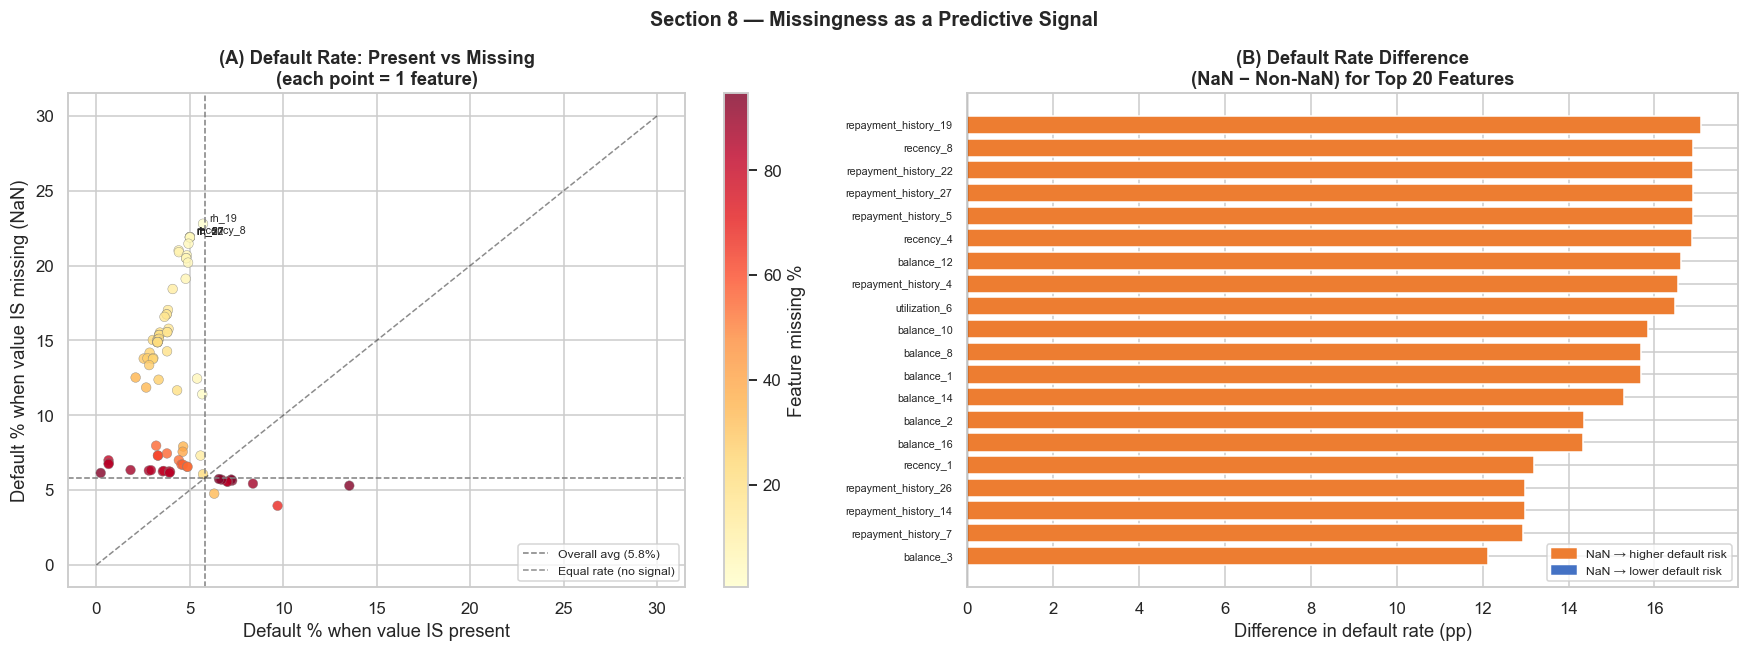


76 features: missing value → HIGHER default risk (event absence = bad signal)
10 features: missing value → LOWER default risk (event absence = good signal)
→ Both directions are informative — missingness flags will be added in Part 3


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Section 8 — Missingness as a Predictive Signal", fontsize=13, fontweight="bold")

# (A) Scatter: default rate NaN vs non-NaN
ax = axes[0]
sc = ax.scatter(ms_df["dr_when_present"], ms_df["dr_when_null"],
                c=ms_df["null_pct"], cmap="YlOrRd", s=40, alpha=0.8, edgecolors="gray", lw=0.3)
plt.colorbar(sc, ax=ax, label="Feature missing %")
overall = train["label"].mean()*100
ax.axhline(overall, color="gray", linestyle="--", lw=1, label=f"Overall avg ({overall:.1f}%)")
ax.axvline(overall, color="gray", linestyle="--", lw=1)
ax.plot([0,30],[0,30], "k--", lw=1, alpha=0.5, label="Equal rate (no signal)")
ax.set_title("(A) Default Rate: Present vs Missing\n(each point = 1 feature)", fontweight="bold")
ax.set_xlabel("Default % when value IS present")
ax.set_ylabel("Default % when value IS missing (NaN)")
ax.legend(fontsize=8)
# annotate extremes
for _, row in ms_df.head(5).iterrows():
    ax.annotate(row["feature"].replace("repayment_history_","rh_").replace("utilization_","u_"),
                (row["dr_when_present"], row["dr_when_null"]),
                fontsize=7, textcoords="offset points", xytext=(4,2))

# (B) Top 20 features by |diff| — bar chart coloured by direction
ax = axes[1]
top_ms = ms_df.head(20).sort_values("diff_pp")
bar_colors = [ORANGE if v > 0 else BLUE for v in top_ms["diff_pp"]]
ax.barh(top_ms["feature"], top_ms["diff_pp"], color=bar_colors, edgecolor="white")
ax.axvline(0, color="black", lw=0.8)
ax.set_title("(B) Default Rate Difference\n(NaN − Non-NaN) for Top 20 Features", fontweight="bold")
ax.set_xlabel("Difference in default rate (pp)")
pos_p = mpatches.Patch(color=ORANGE, label="NaN → higher default risk")
neg_p = mpatches.Patch(color=BLUE,   label="NaN → lower default risk")
ax.legend(handles=[pos_p, neg_p], fontsize=8)
ax.tick_params(axis="y", labelsize=7)

plt.tight_layout(); plt.show()
print(f"\n{(ms_df['diff_pp']>0).sum()} features: missing value → HIGHER default risk (event absence = bad signal)")
print(f"{(ms_df['diff_pp']<0).sum()} features: missing value → LOWER default risk (event absence = good signal)")
print(f"→ Both directions are informative — missingness flags will be added in Part 3")

---
## 9 — Key EDA Findings & Modelling Implications

| # | Finding | Implication for Modelling |
|---|---|---|
| 1 | **16.3:1 class imbalance** — only 5.8% defaults | Use `class_weight='balanced'` / sample weights. Evaluate with AUC + Avg Precision, not accuracy |
| 2 | **score_1 is a strong standalone predictor** — AUC ≈ 0.82, Gini > 0.6 | Include as feature; use as baseline benchmark |
| 3 | **Utilization features dominate** — highest AUC family (best ~0.75) | Keep all; explore interactions |
| 4 | **Repayment history is second-strongest** — 31 features, best AUC ~0.73 | High feature count — tree models handle well |
| 5 | **NaN is informative** — both higher AND lower default rate depending on feature | Add binary missingness flags for all features with >5% null |
| 6 | **Recency NaN patterns split sharply** — absence of events strongly predictive | Missingness flags especially important here |
| 7 | **Categorical features show clear gradient** — financial_situation_4/5 categories span a wide default rate range | One-hot encode; don't drop |
| 8 | **Features are not highly redundant** — few pairs above r=0.85 within top 30 | No aggressive feature selection needed; tree models handle correlated features |
| 9 | **Balance & spend_behaviour have moderate power** — AUC 0.55–0.65 | Keep all; contribute incrementally |

### → Part 3: Feature Engineering & Preprocessing
- Add 79 missingness indicator flags
- Median imputation for numeric NaNs (fit on train only)
- One-hot encode `financial_situation_4` and `financial_situation_5`
- Apply class weighting (16.3:1 ratio)